# **Classification on Human Activity Recognition Using Smartphones Dataset**
## AI 221 Assignment 09

Submitted by: **Pangilinan, Reignel Bernice** 2018-01460 \\


Dataset reference: \\
[1] Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., & Parra, X. (2013). Human Activity Recognition Using Smartphones [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C54S4K.

\\

Code is based on Dr. K. Pilario's work in https://github.com/kspilario/AI221/blob/main/Neural_Networks/autoencoder_iris.ipynb

\\

Note: Before re-running the code, please make sure that the directories of the files containing the data is changed according to where the files are stored in your device.

## **Preliminaries**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np    # Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import time

from warnings import filterwarnings
filterwarnings("ignore")

# Load the pre-split dataset (80-20 split)
path = r"/content/drive/My Drive/AI 221/assignment_09_dataset/"
X_train = pd.DataFrame(np.loadtxt(path + "X_train.txt"))   # Features in training set
X_test = pd.DataFrame(np.loadtxt(path + "X_test.txt"))   # Features in test set
y_train = pd.DataFrame(np.loadtxt(path + "y_train.txt"))   # Labels in training set
y_test = pd.DataFrame(np.loadtxt(path + "y_test.txt"))   # Labels in test set

print("========== TRAINING SET ==========")
display(pd.concat((X_train, y_train), axis = 1))

print("\n========== TEST SET ==========")
display(pd.concat((X_test, y_test), axis = 1))

========== TRAINING SET ==========


,0,1,2,3,4,5,6,7,8,9,...,552,553,554,555,556,557,558,559,560,0
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5.0
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5.0
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5.0
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5.0
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,2.0
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,2.0
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,2.0
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,2.0



========== TEST SET ==========


,0,1,2,3,4,5,6,7,8,9,...,552,553,554,555,556,557,558,559,560,0
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,5.0
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,5.0
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,5.0
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,5.0
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2.0
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2.0
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2.0
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,2.0


## **Exploratory Data Analysis (EDA)**

It is difficult to do other EDA tasks, such as obtaining the correlation matrix, on the dataset given the high number of features it contains so we are limited to understanding the descriptive statistics of the features instead. What we do know is that there are 6 classes, each corresponding to the following 6 activities: (1) walking, (2) walking upstairs, (3) walking downstairs, (4) sitting, (5) standing, (6) laying down. We assume that the encoded labels pertain to the mentioned activities in order.

In [ ]:
## Check the size of the dataframes (that the number of rows of the features agrees with the target's)
# Documentation says that there are no missing values in the dataset. We trust the authors on this.
print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")
print(f"y_train size: {y_train.shape}")
print(f"y_test size: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")


## Generate the descriptive statistics of each set
print("\nX_train descriptive statistics:")
display(X_train.describe())

print("\nX_test descriptive statistics:")
display(X_test.describe())


X_train size: (7352, 561)
X_test size: (2947, 561)
y_train size: (7352, 1)
y_test size: (2947, 1)
Number of classes: 6

X_train descriptive statistics:


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000



X_test descriptive statistics:


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,0.130236,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.231018,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-0.785543,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.008433,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,0.142676,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,0.288320,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113


## **Classification using a Fully-connected Feed-forward Neural Network**

In [ ]:
! pip install keras-tuner

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
import keras_tuner as kt

def ANN(X_train, X_test, y_train, y_test):
  """
    Function that performs classification using a fully-connected feed-forward neural network with hyperparameter tuning.
    Input:
        X_train: Training set (scaled).
        X_test: Test set (scaled).
        y_train: Training labels (encoded).
        y_test: Test labels (encoded).

    Returns:
        None
  """

  # Define a function that builds the model
  def build_model(hyperparams):
    model = Sequential([Input(shape = (X_train.shape[1],)),
                        Dense(units = hyperparams.Int("units", min_value = 32, max_value = 512, step = 32), activation = "relu"),
                        Dense(10, activation = "softmax")])

    model.compile(optimizer = Adam(hyperparams.Choice("learning_rate", values = [1e-2, 1e-3, 1e-4])),
                  loss = SparseCategoricalCrossentropy(),
                  metrics = [SparseCategoricalAccuracy()])
    return model

  # Tune the hyperparameters
  tuner = kt.Hyperband(build_model,
                       objective = "val_sparse_categorical_accuracy",
                       max_epochs = 10,
                       factor = 3,
                       directory = "my_dir",
                       project_name = "intro_to_kt")

  tuner.search(X_train, y_train, epochs = 5, validation_split = 0.2)

  # Get the best hyperparameters
  best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

  # Build the model with the optimal hyperparameters and train it on the full training data
  model = tuner.hypermodel.build(best_hps)
  model.fit(X_train, y_train, epochs = 10)

  # Evaluate the model
  test_loss, test_acc = model.evaluate(X_test, y_test)
  print(f"\nTest accuracy using ANN: {test_acc}")
  print(f"Classification report using ANN:\n{classification_report(y_test, np.argmax(model.predict(X_test), axis = 1))}")

  cm = confusion_matrix(y_test, np.argmax(model.predict(X_test), axis = 1))
  ConfusionMatrixDisplay(cm, display_labels = list(np.unique(y_train))).plot(cmap = plt.cm.Blues, colorbar = False)
  plt.title("Confusion Matrix using ANN")
  plt.tight_layout()
  plt.show()


### **Without dimensionality reduction methods**

Reloading Tuner from my_dir/intro_to_kt/tuner0.json
Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.9943 - sparse_categorical_accuracy: 0.7797
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2848 - sparse_categorical_accuracy: 0.9390
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.4357 - sparse_categorical_accuracy: 0.9406
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.2379 - sparse_categorical_accuracy: 0.9306
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3777 - sparse_categorical_accuracy: 0.9651
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.7164 - sparse_categorical_accuracy: 0.9596
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5607 - sparse_categorical_accuracy: 0.9721
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5273 - sparse_categorical_accuracy: 0.9656
Epoch 9/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2250 - sparse_categorical_accuracy: 0.

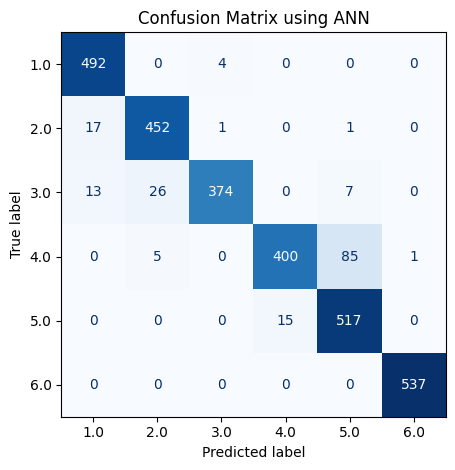

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ANN(X_train, X_test, y_train, y_test)

## **Classification after dimensionality reduction**

### **Using PCA**

Reloading Tuner from my_dir/intro_to_kt/tuner0.json
Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4080 - sparse_categorical_accuracy: 0.8823
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1157 - sparse_categorical_accuracy: 0.9741
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1556 - sparse_categorical_accuracy: 0.9762
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1526 - sparse_categorical_accuracy: 0.9836
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1432 - sparse_categorical_accuracy: 0.9851
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1317 - sparse_categorical_accuracy: 0.9849
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1135 - sparse_categorical_accuracy: 0.9911
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0337 - sparse_categorical_accuracy: 0.9957
Epoch 9/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0104 - sparse_categorical_accuracy: 0.9986
Epo

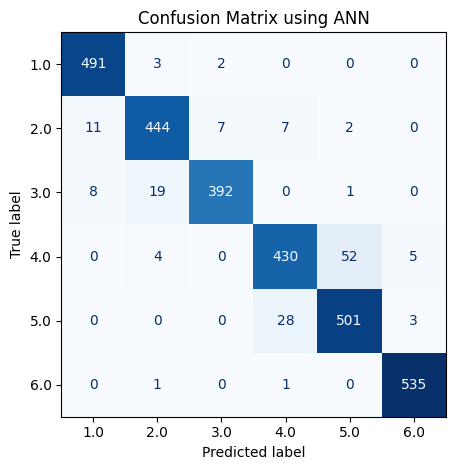

In [ ]:
from sklearn.decomposition import PCA

# Reduce data to n principal components
pca = PCA(n_components = int(0.50*X_train.shape[1]))
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Classify using ANN
ANN(X_train_pca, X_test_pca, y_train, y_test)

### **Using an autoencoder**

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)            │ (None, 2)                   │           2,258 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_10 (Sequential)           │ (None, 561)                 │           2,817 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,075 (19.82 KB)

 Trainable params: 5,075 (19.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.8452
Epoch 2/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8117
Epoch 3/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8055
Epoch 4/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7958
Epoch 5/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8109
Epoch 6/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7812
Epoch 7/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7602
Epoch 8/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7956
Epoch 9/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.7672
Epoch 10/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7769
Epoch 11/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7777
Epoch 12/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7713
Epoch 13/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7859
Epoch 14/1000
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7733
Epoch 15/1000
230/230 ━━━━━━━

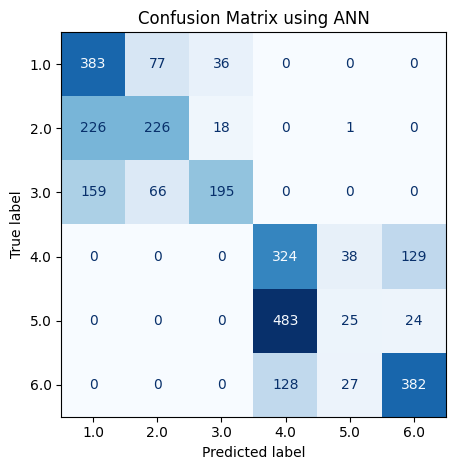

In [ ]:
from tensorflow import keras
# Reduce data via autoencoder
encoder = Sequential([Dense(4, input_shape = [X_train.shape[1]], activation = "relu"),
                      Dense(2, activation = "relu")])
decoder = Sequential([Dense(4, input_shape=[2], activation = "relu"),
                      Dense(X_train.shape[1], activation = "relu")])
autoencoder = Sequential([encoder, decoder])
autoencoder.summary()
autoencoder.compile(loss = "mse", optimizer = keras.optimizers.Adam(learning_rate = 0.005))
history = autoencoder.fit(X_train, X_train, epochs = 1000)
X_train_sae = encoder.predict(X_train)
X_test_sae = encoder.predict(X_test)

# Classify using ANN
ANN(X_train_sae, X_test_sae, y_train, y_test)

## **Conclusions**

Summary of Results

|                             | Accuracy  |
|-----------------------------|----------------|
| SVM [1]                     | 0.96           |
| ANN                         | 0.94           |
| ANN (after PCA)             | 0.95           |
| ANN (after autoencoder)     | 0.52           |



Based on the results, we see that the ANN model was unable to beat the performance of the SVM model used in [1], albeit not significantly. While it is generally the case that SVM is the best classification model for multiclass classification problems, there is only a 0.02 difference between the SVM and ANN results. On the other hand, it is only a 0.01 difference between SVM and the ANN model after PCA. The number of components for PCA was chosen via trial-and-error and it was found that the number of components that gives the best accuracy is half the number of features (n = 280). Moreover, the accuracy decreased significantly when autoencoder was used as the dimensionality reduction method. This low accuracy combined with the amount of time needed to actually execute the autoencoder (~20-25 minutes) does not make it the most ideal dimensionality reduction method for ANN for this dataset. In this case, PCA (n = 280 components) + ANN is the challenger model against SVM for the given dataset.

If we assume that the following are the class labels: (1) walking, (2) walking upstairs, (3) walking downstairs, (4) sitting, (5) standing, and (6) laying down, it appears that the most number of misclassification in the ANN model without dimensionality reduction and after PCA is class STANDING misclassified as SITTING. The raw data of the signals (experiment itself can actually be viewed in the linked video in the repository) actually show that there is some similarity between the two so it is not surprising that the model confuses them. The confusion matrix of the autoencoder + ANN looks exactly that: confused, further stressing that it is not the most ideal nor practical approach to this problem.